In [46]:
# Install required libraries
!pip install yfinance

In [47]:
import pandas as pd
import datetime as dt
import datetime
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import tensorflow as tf
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.layers import Dense, Dropout, LSTM, Input, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam


In [48]:
# Get the data from yfinance
stock_symbol = "AAPL"                        # For sample take apple company share data
end_date = datetime.datetime.today().date()
start_date = end_date - datetime.timedelta(days=5*365)  # Get 5 years backdata

stock_data = yf.download(stock_symbol, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [49]:
# see the sample data points
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-02-06,78.821342,78.823769,77.621612,78.181488,105425600
2020-02-07,77.749954,78.568680,77.256774,78.318447,117684000
2020-02-10,78.119217,78.119217,76.248539,76.328708,109348800
2020-02-11,77.647919,78.690158,77.429269,78.617278,94323200
2020-02-12,79.491890,79.496746,78.099807,78.099807,113730400


In [78]:
stock_data.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-01-28,238.259995,240.190002,230.809998,230.850006,75707600
2025-01-29,239.360001,239.860001,234.009995,234.119995,45486100
2025-01-30,237.589996,240.789993,237.210007,238.669998,55658300
2025-01-31,236.000000,247.190002,233.440002,247.190002,101075100
2025-02-03,228.009995,231.830002,225.699997,229.990005,72896300


In [50]:
# Save to CSV
stock_data.to_csv(f"{stock_symbol}_data.csv")

In [51]:
df=stock_data

In [52]:
#Basic EDA
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1255 entries, 2020-02-06 to 2025-02-03
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1255 non-null   float64
 1   (High, AAPL)    1255 non-null   float64
 2   (Low, AAPL)     1255 non-null   float64
 3   (Open, AAPL)    1255 non-null   float64
 4   (Volume, AAPL)  1255 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB


In [53]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03
mean,155.180963,156.755257,153.438728,155.039239,8.912468e+07
std,42.084696,42.240908,41.861143,42.051678,5.290213e+07
min,54.509750,55.513118,51.652709,55.411081,2.323470e+07
25%,129.042641,130.559219,127.363257,129.172792,5.479325e+07
50%,152.668610,154.782860,150.878329,152.427267,7.499350e+07
75%,179.399841,180.831813,177.336460,179.530843,1.044896e+08
max,259.019989,260.100006,257.630005,258.190002,4.265100e+08


In [54]:
df.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


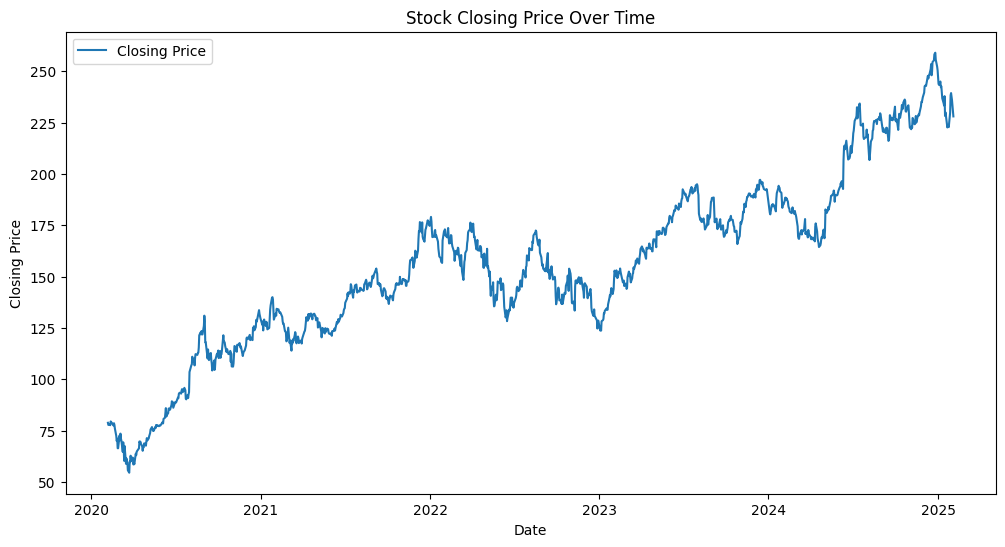

In [55]:
# Visualizing stock closing price
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Closing Price')
plt.title('Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.show()

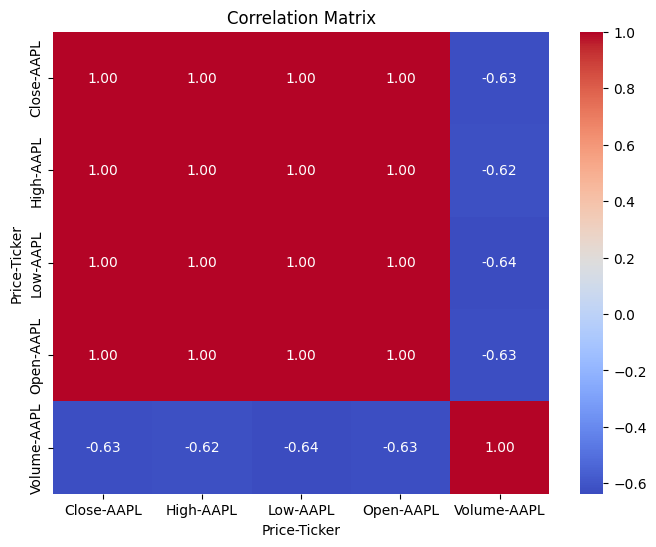

In [56]:
# Correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [57]:
#Plotting moving averages of 100
ma100 = df.Close.rolling(100).mean()

Text(0.5, 1.0, 'Graph Of Moving Averages Of 100 Days')

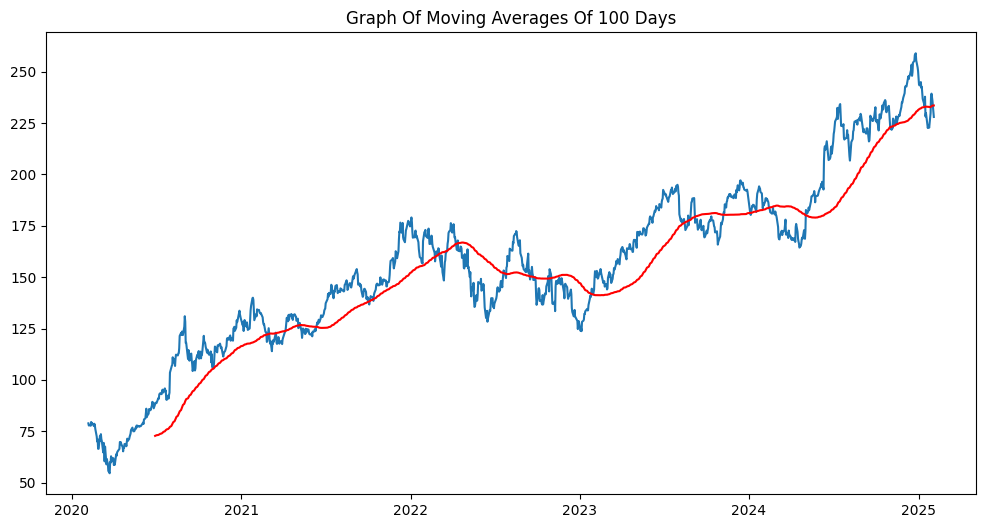

In [58]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.title('Graph Of Moving Averages Of 100 Days')

In [59]:
#Defining 200 days moving averages and plotting comparision graph with 100 days moving averages

In [60]:
ma200 = df.Close.rolling(200).mean()

Text(0.5, 1.0, 'Comparision Of 100 Days And 200 Days Moving Averages')

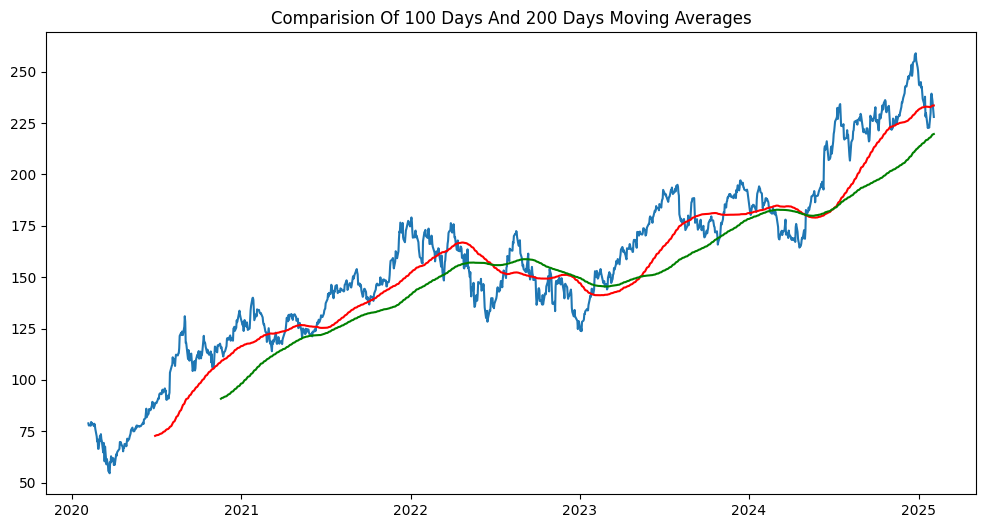

In [61]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')
plt.title('Comparision Of 100 Days And 200 Days Moving Averages')

In [62]:
# Select the 'Close' price as the target variable
data = df[['Close']].values

In [63]:
#Using MinMax scaler for normalization of the dataset

In [64]:
scaler = MinMaxScaler(feature_range=(0,1))

In [65]:
data_scaled = scaler.fit_transform(data)

In [66]:
# prepare dataset for LSTM model as per length
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

In [67]:
# make dataset into sequences
seq_length = 60
X, y = create_sequences(data_scaled, seq_length)

In [68]:
# Split into training and testing sets
split = int(len(X) * 0.8)                 # currently we are considering 80% data for training and 20% for testing
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [69]:
model = Sequential([
    Input(shape=(seq_length, 1)),
    LSTM(units=50, activation='relu', return_sequences=True),
    Dropout(0.2),
    LSTM(units=60, activation='relu', return_sequences=True),
    Dropout(0.2),
    LSTM(units=80, activation='relu', return_sequences=True),
    Dropout(0.2),
    LSTM(units=120, activation='relu'),
    Dropout(0.2),
    Dense(units=1)
])

In [70]:
# model = Sequential([
#     Input(shape=(seq_length, 1)),
#     LSTM(units=64, activation='relu', return_sequences=True),
#     BatchNormalization(),
#     Dropout(0.2),

#     LSTM(units=128, activation='relu', return_sequences=True),
#     BatchNormalization(),
#     Dropout(0.3),

#     LSTM(units=256, activation='relu', return_sequences=True),
#     BatchNormalization(),
#     Dropout(0.4),

#     LSTM(units=128, activation='relu'),
#     BatchNormalization(),
#     Dropout(0.5),

#     Dense(units=64, activation='relu'),
#     Dense(units=32, activation='relu'),
#     Dense(units=1)
# ])

In [71]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                       │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_13 (LSTM)                       │ (None, 60, 60)              │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 60, 60)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_14 (LSTM)                       │ (None, 60, 80)              │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 60, 80)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_15 (LSTM)                       │ (None, 120)                 │          96,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 120)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             121 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])

In [73]:
# Train model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 28s 396ms/step - loss: 0.1176 - mae: 0.2893 - val_loss: 0.0204 - val_mae: 0.1246
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0079 - mae: 0.0716 - val_loss: 0.0075 - val_mae: 0.0702
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0046 - mae: 0.0551 - val_loss: 0.0075 - val_mae: 0.0673
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0041 - mae: 0.0509 - val_loss: 0.0044 - val_mae: 0.0507
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0039 - mae: 0.0488 - val_loss: 0.0043 - val_mae: 0.0501
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0034 - mae: 0.0459 - val_loss: 0.0049 - val_mae: 0.0548
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0033 - mae: 0.0462 - val_loss: 0.0066 - val_mae: 0.0661
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0037 - mae: 0.0472 - val_loss: 0.0032 - val_mae: 0.0457
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0

In [74]:
# save the model
model.save('lstm_model.h5')

In [75]:
# Make predictions
y_pred = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step


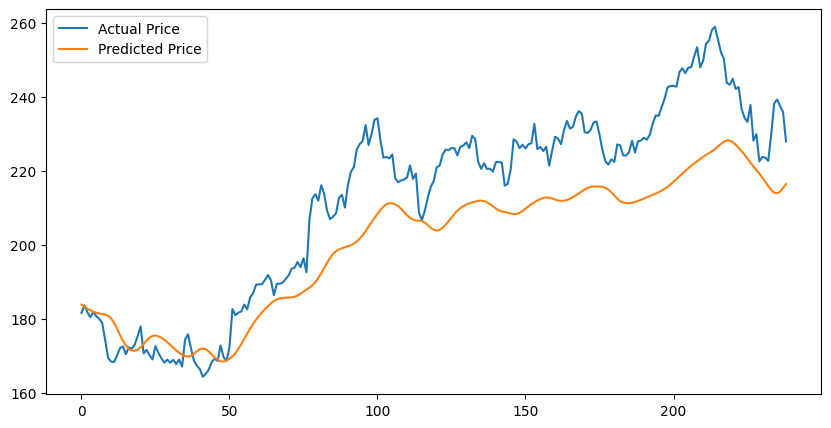

In [76]:
# Plot results
plt.figure(figsize=(10, 5))
plt.plot(y_test, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')
plt.legend()
plt.show()

In [77]:
# Predict next day's price
last_60_days = data_scaled[-seq_length:]
last_60_days = last_60_days.reshape(1, seq_length, 1)
next_day_pred = model.predict(last_60_days)
next_day_pred = scaler.inverse_transform(next_day_pred)
print("Predicted Next Day's Closing Price:", next_day_pred[0, 0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Next Day's Closing Price: 217.45113
